# Does price get "pulled back" to the volume point of control? 🧲
### The volume-profile POC — the level traders swear acts like a magnet — in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Price_returns_to_POC%3F: Busted](https://img.shields.io/badge/Price_returns_to_POC%3F-Busted-8b949e?style=flat-square)

Here's a chart-room favourite. Every day, some price level trades **way more volume** than the rest — the **Point of Control (POC)**, the price the market "agreed on" most. The folklore says that level is a **magnet**: if tomorrow opens away from it, price will get **pulled back** to touch it. So you fade the open *toward* yesterday's POC and target the level.

It's a tidy story. The trouble is that on a volatile intraday tape, *almost any* level near the open gets touched eventually — so "price came back to the POC" can be true **without the POC being special at all**. The honest test isn't "how often is the POC touched?" — it's "is the POC touched **more often than a random level the same distance away**?"

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A loud data note.** Intraday 5-minute bars on Yahoo only go back **~60 trading days**, so this is a *short-span* study on a 6-name liquid basket (SPY/QQQ/AAPL/MSFT/NVDA/TSLA). And intraday levels are exactly where **the spread eats you** — capacity is the whole story. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from volume_profile_poc import data, strategy as st

AS_OF = pd.Timestamp("2026-06-23")     # last COMPLETE session in the pinned cache
HAVE_REAL = data.have_real()
if HAVE_REAL:
    EV = data.load_real()
    EV = EV[EV["date"] <= AS_OF].reset_index(drop=True)
else:
    EV = None
print("real POC cache present:", HAVE_REAL,
      "| sessions:", (0 if EV is None else len(EV)),
      "| fingerprint:", (None if EV is None else data.fingerprint(EV)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2026-03-31', 'end': '2026-06-23', 'as_of': '2026-06-23', 'fingerprint': '10ce6e8c7ecb', 'n_names': 6, 'n_sessions': 348, 'n_events': 336, 'poc_rate': 49.7, 'ctrl_rate': 53.3, 'edge_pp': -3.6, 'poc_ci': (44.4, 55.0), 'ctrl_ci': (47.9, 58.5), 't_paired': -1.28, 't_hac': -1.32, 'placebo_p': 0.682, 'placebo_mean': 50.5, 'fade_n': 336, 'fade_hit': 49.7, 'fade_gross': -0.102, 'fade_net': -0.122, 'fade_gross_t': -1.46, 'fade_net_t': -1.75, 'breakeven_bps': -5.1, 'tol': [(0, 49.7, 53.3, -3.6, -1.32), (5, 52.1, 54.8, -2.7, -1.04), (10, 54.2, 57.1, -3.0, -1.14), (20, 58.3, 61.6, -3.3, -1.26)], 'by_tk': [('AAPL', 56, 62.5, 62.5, 0.0), ('MSFT', 57, 42.1, 42.1, 0.0), ('NVDA', 56, 51.8, 53.6, -1.8), ('QQQ', 58, 44.8, 43.1, 1.7), ('SPY', 52, 46.2, 48.1, -1.9), ('TSLA', 57, 50.9, 61.4, -10.5)], 'syn': [(0.0, 49.3, 48.7, 0.6, 0.44, 0.011), (0.7, 76.5, 61.0, 15.5, 7.49, 0.0)]}


real POC cache present: True | sessions: 348 | fingerprint: 10ce6e8c7ecb


## The answer first

| Question | Answer |
|---|---|
| Does price come back to yesterday's POC? | **About half the time — 50%.** Which *sounds* like a magnet… until you check the control. |
| Is that more than a **random** level the same distance away? | **No — it's *less*.** A random level gets touched **53%** of the time, *more* than the POC (-3.6 points). The POC is, if anything, **slightly stickier to avoid**. |
| Is the difference real or noise? | **Noise.** The gap isn't statistically distinguishable from zero (t ≈ -1.3). |
| Could you trade the fade? | **No.** Fading the open toward the POC loses money **before you even pay the spread** (-0.10% gross), and intraday spreads are exactly what kills levels. |

> The POC is a real, observable level — but the "magnet" is an illusion of a volatile tape: any nearby level gets touched a lot. The POC isn't special.

## 1 · The claim

> *"The Point of Control is where the most volume traded — it's 'fair value' for the session. Price is drawn back to it like a magnet. If we open above the POC, fade short toward it; if we open below, buy toward it. The level gets respected."*

This is the heart of **Volume Profile** / Market Profile trading (J. Peter Steidlmayer's framework, popularised by a generation of futures day-traders). The POC, the Value Area, the "naked" POCs that supposedly get revisited — it's a whole vocabulary. We're testing its single most central claim: **price returns to the POC.**

## 2 · So what?

If the POC really were a magnet, it would be a clean, mechanical intraday edge: a known level every morning, a direction to fade, a target to exit at. Day-traders pay for exactly this.

But there's a trap baked into the claim, and it's the same trap that inflates *most* support/resistance lore: on a day where the stock swings around, the high and low cover a lot of ground, so **a level near the open is touched whether or not it means anything**. "It came back to the POC" feels like confirmation, but the right question is whether the POC beats a **coin-flip level** placed the same distance from the open. If it doesn't, the magnet is just **volatility**.

## 3 · How would we even know?

We pull **5-minute bars** for a 6-name liquid basket over the last **~60 trading days** (2026-03-31 → 2026-06-23). For each session we build a **volume profile** — bin the day's volume by price, take the busiest bin: that's the POC. Then for the *next* session we ask:

1. **Did the day's range touch the prior POC?** (the believer's claim)
2. **Did it touch a *random control* level the same distance from the open?** (the honest benchmark — same volatility, no special meaning)
3. **Would fading the open toward the POC have made money** after a realistic spread?

**The mirage line, declared up front:** if the POC's touch-rate is **not clearly above** the random control's — or if the fade is gross-negative — we stamp it a **mirage**. We're not asking "is the POC ever touched," we're asking "is it *special*."

## 4 · The teardown — let's actually look

**The decisive picture.** How often is the POC touched, versus a random level the same distance from the open? If the magnet is real, the green (POC) bar towers over the grey (control) bar.

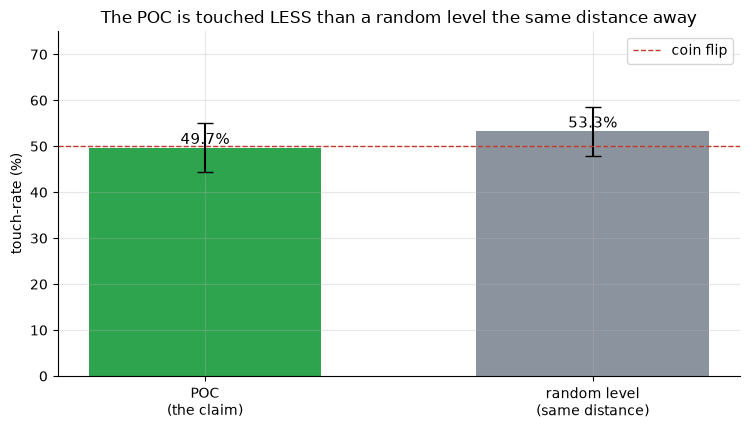

POC touch 49.7%   random-level touch 53.3%   edge -3.6 pp


In [2]:
if HAVE_REAL:
    rs = st.reversion_stats(EV)
    poc, ctrl = rs['poc_rate']*100, rs['ctrl_rate']*100
    poc_ci, ctrl_ci = rs['poc_ci'], rs['ctrl_ci']
else:
    poc, ctrl = R['poc_rate'], R['ctrl_rate']
    poc_ci = tuple(c/100 for c in R['poc_ci']); ctrl_ci = tuple(c/100 for c in R['ctrl_ci'])
fig, ax = plt.subplots(figsize=(7.6, 4.4))
bars = ax.bar(['POC\n(the claim)', 'random level\n(same distance)'], [poc, ctrl],
              color=[GREEN, GREY], width=.6)
errs = [[poc-poc_ci[0]*100, poc_ci[1]*100-poc],[ctrl-ctrl_ci[0]*100, ctrl_ci[1]*100-ctrl]]
ax.errorbar([0,1],[poc,ctrl], yerr=np.array(errs).T, fmt='none', ecolor='k', capsize=6)
ax.axhline(50, ls='--', c=RED, lw=1, label='coin flip')
for i,v in enumerate([poc,ctrl]): ax.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom',fontsize=11)
ax.set_ylabel('touch-rate (%)'); ax.set_ylim(0, 75)
ax.set_title('The POC is touched LESS than a random level the same distance away')
ax.legend(); plt.tight_layout(); plt.show()
print(f'POC touch {poc:.1f}%   random-level touch {ctrl:.1f}%   edge {poc-ctrl:+.1f} pp')

There's the whole study in one chart. The POC is touched **50%** of the time — but a random level placed the *same distance* from the open is touched **53%**, *more* than the POC. The "magnet" doesn't even keep pace with a coin-flip level. The confidence bars overlap heavily: this is noise, and what little sign there is points the **wrong way**.

**Does loosening the definition of "touch" rescue it?** Maybe an exact range-straddle is too strict — let's count a touch if price comes *within* a few basis points of the POC, and do the same for the control. Watch whether the edge ever turns positive.

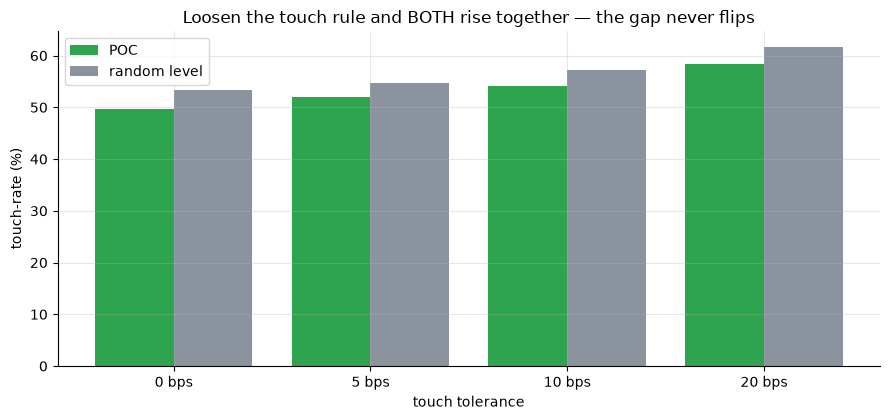

edge by tolerance (pp): [-3.6, -2.7, -3.0, -3.3]


In [3]:
tols = [t[0] for t in R['tol']]
if HAVE_REAL:
    poc_r = [st.reversion_stats(EV, tol=t/1e4)['poc_rate']*100 for t in tols]
    ctrl_r = [st.reversion_stats(EV, tol=t/1e4)['ctrl_rate']*100 for t in tols]
else:
    poc_r = [t[1] for t in R['tol']]; ctrl_r = [t[2] for t in R['tol']]
x = np.arange(len(tols))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(x-.2, poc_r, .4, color=GREEN, label='POC')
ax.bar(x+.2, ctrl_r, .4, color=GREY, label='random level')
ax.set_xticks(x); ax.set_xticklabels([f'{t} bps' for t in tols])
ax.set_xlabel('touch tolerance'); ax.set_ylabel('touch-rate (%)')
ax.set_title('Loosen the touch rule and BOTH rise together — the gap never flips')
ax.legend(); plt.tight_layout(); plt.show()
print('edge by tolerance (pp):', [round(p-c,1) for p,c in zip(poc_r,ctrl_r)])

Loosening the rule lifts **both** touch-rates together — of course it does, a wider net catches both the POC and the random level. The **gap stays negative** at every tolerance. There's no setting where the POC beats a coin-flip level.

## 5 · The verdict

- **Signal — None.** The POC is touched **50%** of the time vs **53%** for a distance-matched random level (edge **-3.6 pp**, t ≈ -1.3). No magnet — just volatility touching nearby levels.
- **Tradability — Mirage.** Fading the open toward the POC is **gross-negative** (**-0.10%** per trade) *before* any spread — and intraday spreads are where levels go to die.
- **"Price returns to the POC"? — Busted.** It returns no more (a touch less) than to a random level. The claim mistakes a feature of volatile tape for a force.

## 6 · Could you actually trade it? — the spread finishes it off

Even granting the magnet, here's the fade — short above the POC / long below, target the level — **gross** (before costs) vs **net** (after a tiny **1 bp** per-leg spread, the *best case* for a liquid name).

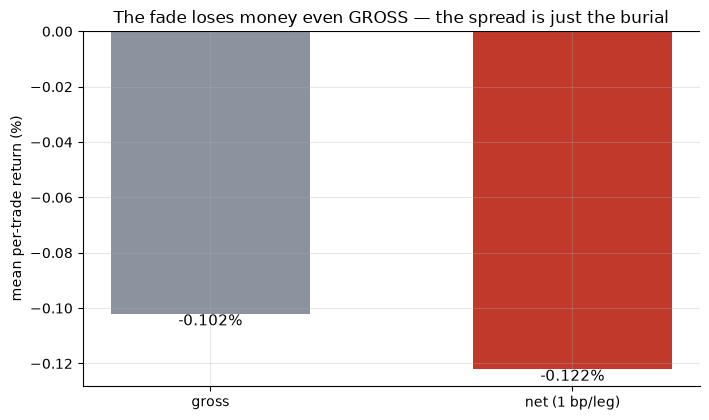

fade gross -0.102%   net -0.122%   (break-even one-way cost -5.1 bps)


In [4]:
if HAVE_REAL:
    fd = st.fade_trade(EV, cost_bps=1.0)
    g, nv = fd['gross_mean']*100, fd['net_mean']*100
else:
    g, nv = R['fade_gross'], R['fade_net']
fig, ax = plt.subplots(figsize=(7.2, 4.3))
ax.bar(['gross', 'net (1 bp/leg)'], [g, nv], color=[GREY, RED], width=.55)
ax.axhline(0, c='k', lw=.8)
for i,v in enumerate([g,nv]): ax.annotate(f'{v:+.3f}%',(i,v),ha='center',va='top',fontsize=11)
ax.set_ylabel('mean per-trade return (%)')
ax.set_title('The fade loses money even GROSS — the spread is just the burial')
plt.tight_layout(); plt.show()
print(f'fade gross {g:+.3f}%   net {nv:+.3f}%   (break-even one-way cost {R["breakeven_bps"]:+.1f} bps)')

The fade is **-0.10%** per trade *gross* — it loses before costs, so there's no edge to pay a spread out of (break-even cost is **-5.1 bps**, i.e. negative — there's nothing there). The 1 bp/leg charge is generous for a liquid ETF; widen it to a realistic intraday spread and it's worse. **Mirage**, full stop.

## 7 · Going further 🚪

- **The honesty trick generalises.** Every support/resistance claim — round numbers, prior highs, VWAP, the POC — has to beat a **distance-matched random level**, not zero. On a volatile tape, *everything* gets touched. (See the desk's round-numbers and research-method demos.)
- **Short span, named loudly.** Yahoo caps 5m bars at ~60 days, so this is **336 events** on 6 names — enough to say "no magnet here," not enough to chase a tiny conditional edge. Re-run on futures tick data (ES, NQ) over years for the definitive test.
- **Variants to try.** "Naked" POCs (untouched for days), the Value Area edges instead of the POC, or continuation (does price *accelerate* away from the POC?) rather than reversion.

*Think the POC is a real magnet? Show its touch-rate clearing a distance-matched random control with t ≥ 2 on a longer tape — then we'll talk.*